In [5]:
import pandas as pd

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
df = pd.read_csv('/content/drive/MyDrive/DL_assignment/IMDB Dataset.csv')

In [8]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [9]:
### Drop NaN values
df = df.dropna()

In [10]:
### Get the independent Features
x = df.drop('sentiment', axis=1)

In [11]:
### Get the Dependent Feaatures
y=df['sentiment'].map({'positive':1, 'negative':0})

In [12]:
x.shape

(50000, 1)

In [13]:
y.shape

(50000,)

In [14]:
y

,sentiment
0,1
1,1
2,1
3,0
4,1
...,...
49995,1
49996,0
49997,0
49998,0


In [15]:
import tensorflow as tf

In [16]:
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Bidirectional

In [17]:
### Vocabulary size
voc_size = 5000

**One-Hot Representation**

In [18]:
messages = x.copy()

In [19]:
messages['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [20]:
messages.reset_index(inplace=True)

In [21]:
import re
import nltk
from nltk.corpus import stopwords
from tqdm import tqdm

In [22]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [23]:
### Data Preprocessing
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))
corpus = []
for i in tqdm(range(len(messages))):
  text = re.sub('<.*?>',  ' ', messages['review'][i])
  review = re.sub('[^a-zA-Z]', ' ', text)
  review = review.lower()
  review = review.split()
  review = [ps.stem(word) for word in review if word not in stop_words]
  review = ' '.join(review)
  corpus.append(review)

100%|██████████| 50000/50000 [01:51<00:00, 448.28it/s]


In [24]:
onehot_repr = [one_hot(words, voc_size)for words in corpus]

In [25]:
sent_length = 400
embedded_docs = pad_sequences(onehot_repr, padding='pre', maxlen=sent_length)
print(embedded_docs)

[[   0    0    0 ... 1109 3709 4854]
 [   0    0    0 ... 2819 2749 1855]
 [   0    0    0 ... 2996 4226 2411]
 ...
 [   0    0    0 ... 4737 2954 2594]
 [   0    0    0 ... 1242  347 3275]
 [   0    0    0 ... 4519 1056 4149]]


In [26]:
embedding_vector_features = 100

model = Sequential()
model.add(Embedding(input_dim=voc_size, output_dim=embedding_vector_features, input_length=sent_length))
model.add(Bidirectional(LSTM(100, dropout=0.2, recurrent_dropout=0.2)))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [27]:
import numpy as np
x_final = np.array(embedded_docs)
y_final = np.array(y)

In [28]:
x_final.shape, y_final.shape

((50000, 400), (50000,))

In [29]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_final, y_final, test_size=0.33, random_state=64)

In [31]:
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=5, batch_size=64)

Epoch 1/5
524/524 ━━━━━━━━━━━━━━━━━━━━ 1244s 2s/step - accuracy: 0.8157 - loss: 0.4208 - val_accuracy: 0.8396 - val_loss: 0.3708
Epoch 2/5
524/524 ━━━━━━━━━━━━━━━━━━━━ 1242s 2s/step - accuracy: 0.8649 - loss: 0.3319 - val_accuracy: 0.8538 - val_loss: 0.3495
Epoch 3/5
524/524 ━━━━━━━━━━━━━━━━━━━━ 1236s 2s/step - accuracy: 0.8778 - loss: 0.3001 - val_accuracy: 0.8405 - val_loss: 0.3635
Epoch 4/5
524/524 ━━━━━━━━━━━━━━━━━━━━ 1228s 2s/step - accuracy: 0.8938 - loss: 0.2721 - val_accuracy: 0.8568 - val_loss: 0.3563
Epoch 5/5
524/524 ━━━━━━━━━━━━━━━━━━━━ 1228s 2s/step - accuracy: 0.9097 - loss: 0.2302 - val_accuracy: 0.8535 - val_loss: 0.3699


In [32]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
scores = model.evaluate(x_test, y_test, verbose=1, batch_size=256)
print("accuracy: %.2f%%" % (scores[1]*100))

65/65 ━━━━━━━━━━━━━━━━━━━━ 39s 527ms/step - accuracy: 0.8499 - loss: 0.3780
accuracy: 85.35%


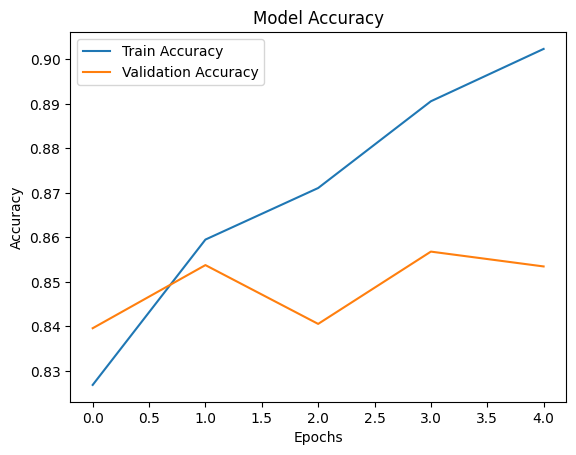

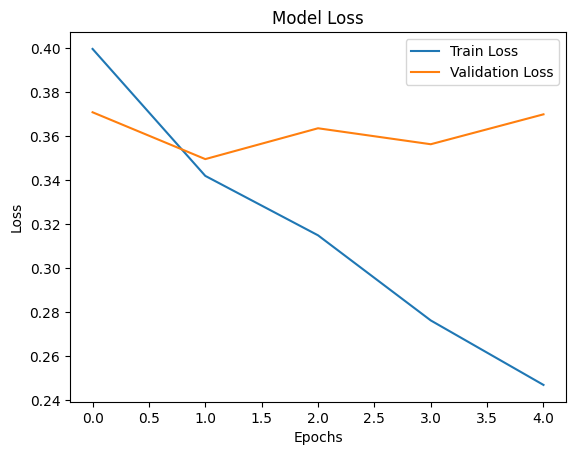

In [33]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [34]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns

y_pred = (model.predict(x_test) > 0.5).astype("int32")

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


516/516 ━━━━━━━━━━━━━━━━━━━━ 214s 413ms/step
Accuracy: 0.8534545454545455
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      8222
           1       0.85      0.86      0.86      8278

    accuracy                           0.85     16500
   macro avg       0.85      0.85      0.85     16500
weighted avg       0.85      0.85      0.85     16500



In [ ]:
model.summary()